# Sound 01: Single Network Analysis

**Question:** What is the structure of the 2000–2010 belief network, and what can we actually conclude from it?

This notebook addresses conceptual gaps in the baseline analysis:
1. **Dimensionality check** — Is this basically a 1D (liberal–conservative) network?
2. **Community detection** — Do beliefs cluster into interpretable domains?
3. **Centrality with dimensionality context** — Are central variables just high PC1 loaders?
4. **Balance with null model** — Is 99% balance surprising or trivially expected?

**Period:** 2000–2010, regularized partial Pearson (alpha=0.2)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from src.loaders.clean_raw_data import clean_datasets
from src.generators.corr_make_network import (
    calculate_correlation_matrix, CorrelationMethod, EdgeSuppressionMethod
)
from src.analyzers.triad_analyzer import count_triads
from src.visualizers.network_visualizer import generate_html_visualization, calculate_network_stats

C:\Users\timbo\miniconda3\Lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
cleaned_df = clean_datasets()

YEARS = list(range(2000, 2011, 2))  # GSS biennial
print(f"Reference period: {YEARS}")

# Build reference network
corr_reg = calculate_correlation_matrix(
    cleaned_df, years_of_interest=YEARS,
    method=CorrelationMethod.PEARSON, partial=True,
    edge_suppression=EdgeSuppressionMethod.REGULARIZATION,
    suppression_params={'regularization': 0.2}, verbose=True
)

print(f"\nReference network: {corr_reg.shape[0]} variables, "
      f"{(np.abs(corr_reg.values) > 0).sum() // 2} non-zero edges")

Loading dataset from from cache...


Done! ✨


Reference period: [2000, 2002, 2004, 2006, 2008, 2010]

CORRELATION NETWORK STATISTICS
Variables filtered out (metadata): 3
Variables included in analysis: 133
Total number of samples: 16971
--------------------------------------------------


Variables removed due to NaN correlations: 12
Remaining variables after NaN filtering: 121
Removed variables (first 10): NATCRIMY, NATRACEY, NATDRUGY, NATARMSY, NATFAREY, NATEDUCY, NATCITYY, MARHOMO, NATAIDY, NATHEALY...
--------------------------------------------------


Sample size statistics for correlations:
  Mean: 28338.9
  Min: 3098
  Max: 71953

Reference network: 121 variables, 376 non-zero edges


## 1.1 Dimensionality Check (PCA)

**Key question:** Is this basically a 1D network? If PC1 explains >40% and PC2 <10%,
the network is approximately one-dimensional and most downstream analyses are less interesting.

In [3]:
# PCA via eigendecomposition of the simple Pearson correlation matrix.
# We can't use raw respondent data because dropna() across 121 variables
# leaves zero complete cases (GSS has heavy missingness). Instead, we
# eigendecompose the pairwise-complete Pearson correlation matrix, which
# is mathematically equivalent to PCA on standardized data.

network_vars = list(corr_reg.columns)

# Build simple Pearson correlation matrix for the same period and variables
corr_simple = calculate_correlation_matrix(
    cleaned_df, years_of_interest=YEARS,
    variables_of_interest=network_vars,
    method=CorrelationMethod.PEARSON, partial=False,
    edge_suppression=EdgeSuppressionMethod.NONE, verbose=False
)

# Align to network variables (some may have been dropped)
pca_vars = [v for v in network_vars if v in corr_simple.columns]
corr_pca = corr_simple.loc[pca_vars, pca_vars].copy()

# Ensure valid correlation matrix (fill diagonal with 1, handle any NaN)
np.fill_diagonal(corr_pca.values, 1.0)
corr_pca = corr_pca.fillna(0)

print(f"PCA input: {len(pca_vars)} variables (eigendecomposition of pairwise Pearson correlation matrix)")
print(f"Using pairwise-complete observations (no respondents dropped)")

PCA input: 121 variables (eigendecomposition of pairwise Pearson correlation matrix)
Using pairwise-complete observations (no respondents dropped)


In [4]:
# Eigendecomposition of the correlation matrix
eigenvalues, eigenvectors = np.linalg.eigh(corr_pca.values)

# Sort by descending eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Clamp any tiny negative eigenvalues to zero (numerical artifact)
eigenvalues = np.maximum(eigenvalues, 0)

# Variance explained
total_var = eigenvalues.sum()
explained = eigenvalues / total_var
cumulative = np.cumsum(explained)

print("Variance explained by top components:")
print(f"  PC1: {explained[0]:.3f} ({explained[0]*100:.1f}%)")
print(f"  PC2: {explained[1]:.3f} ({explained[1]*100:.1f}%)")
print(f"  PC3: {explained[2]:.3f} ({explained[2]*100:.1f}%)")
print(f"  PC4: {explained[3]:.3f} ({explained[3]*100:.1f}%)")
print(f"  PC5: {explained[4]:.3f} ({explained[4]*100:.1f}%)")
print(f"\n  Cumulative PC1-3: {cumulative[2]*100:.1f}%")
print(f"  Cumulative PC1-5: {cumulative[4]*100:.1f}%")
print(f"  Components needed for 50% variance: {np.searchsorted(cumulative, 0.5) + 1}")
print(f"  Components needed for 80% variance: {np.searchsorted(cumulative, 0.8) + 1}")

# Dimensionality verdict
if explained[0] > 0.40 and explained[1] < 0.10:
    print("\n** VERDICT: Network is approximately ONE-DIMENSIONAL. **")
    print("   Centrality and balance findings are less interesting --")
    print("   they mostly just reflect loading on the liberal-conservative axis.")
elif explained[0] > 0.25:
    print("\n** VERDICT: Dominant first dimension, but meaningful higher dimensions exist. **")
else:
    print("\n** VERDICT: Network is genuinely multi-dimensional. **")
    print("   Centrality and community structure are substantively interesting.")

Variance explained by top components:
  PC1: 0.100 (10.0%)
  PC2: 0.058 (5.8%)
  PC3: 0.035 (3.5%)
  PC4: 0.032 (3.2%)
  PC5: 0.025 (2.5%)

  Cumulative PC1-3: 19.3%
  Cumulative PC1-5: 25.0%
  Components needed for 50% variance: 27
  Components needed for 80% variance: 68

** VERDICT: Network is genuinely multi-dimensional. **
   Centrality and community structure are substantively interesting.


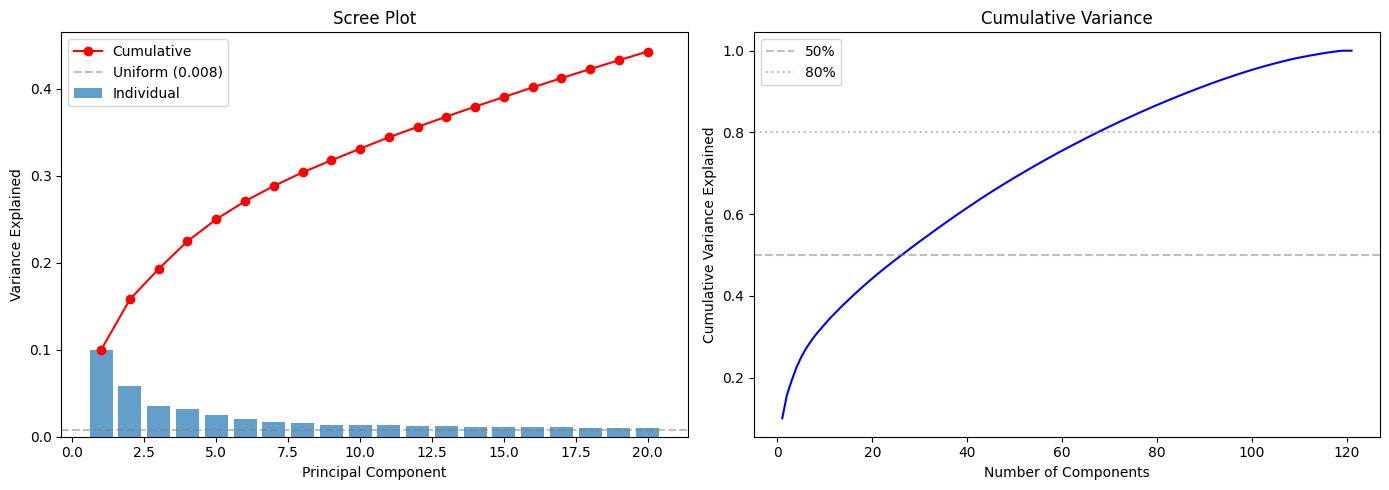

In [5]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scree plot (first 20 components)
n_show = min(20, len(explained))
axes[0].bar(range(1, n_show + 1), explained[:n_show], alpha=0.7, label='Individual')
axes[0].plot(range(1, n_show + 1), cumulative[:n_show], 'ro-', label='Cumulative')
axes[0].axhline(y=1/len(pca_vars), color='gray', linestyle='--', alpha=0.5,
               label=f'Uniform ({1/len(pca_vars):.3f})')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')
axes[0].legend()

# Right: cumulative (all components)
axes[1].plot(range(1, len(cumulative) + 1), cumulative, 'b-')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50%')
axes[1].axhline(y=0.8, color='gray', linestyle=':', alpha=0.5, label='80%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Top variable loadings on PC1 and PC2
# Eigenvectors are columns; loadings = eigenvectors scaled by sqrt(eigenvalue)
loadings = pd.DataFrame(
    eigenvectors[:, :2],
    index=pca_vars,
    columns=['PC1', 'PC2']
)
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings['PC2_abs'] = loadings['PC2'].abs()

print("=== Top 15 variables by |PC1 loading| ===")
print(loadings.sort_values('PC1_abs', ascending=False)[['PC1']].head(15).to_string())
print()
print("=== Top 15 variables by |PC2 loading| ===")
print(loadings.sort_values('PC2_abs', ascending=False)[['PC2']].head(15).to_string())

=== Top 15 variables by |PC1 loading| ===
               PC1
HOMOSEX  -0.181232
LIBMSLM  -0.178592
SPKMSLM   0.177098
SPKCOM    0.174259
LIBCOM   -0.173604
ABSINGLE  0.167743
ABNOMORE  0.167191
ABANY     0.166271
LIBHOMO  -0.164345
COLMSLM   0.163030
LIBATH   -0.162685
ABPOOR    0.160269
COLATH    0.157888
LIBMIL   -0.157794
SPKMIL    0.156370

=== Top 15 variables by |PC2 loading| ===
                           PC2
PRESLAST_DEMREP       0.244780
PARTYID               0.228193
HELPBLK              -0.216582
EQWLTH                0.211984
HELPPOOR             -0.208440
HELPNOT              -0.203605
NATRACE              -0.195718
AFFRMACT             -0.180513
POLVIEWS              0.174871
NATFARE              -0.165902
RACDIF1              -0.151932
WOULDVOTELAST_DEMREP  0.150626
POLHITOK              0.149794
NATCHLD              -0.147458
WRKWAYUP              0.137226


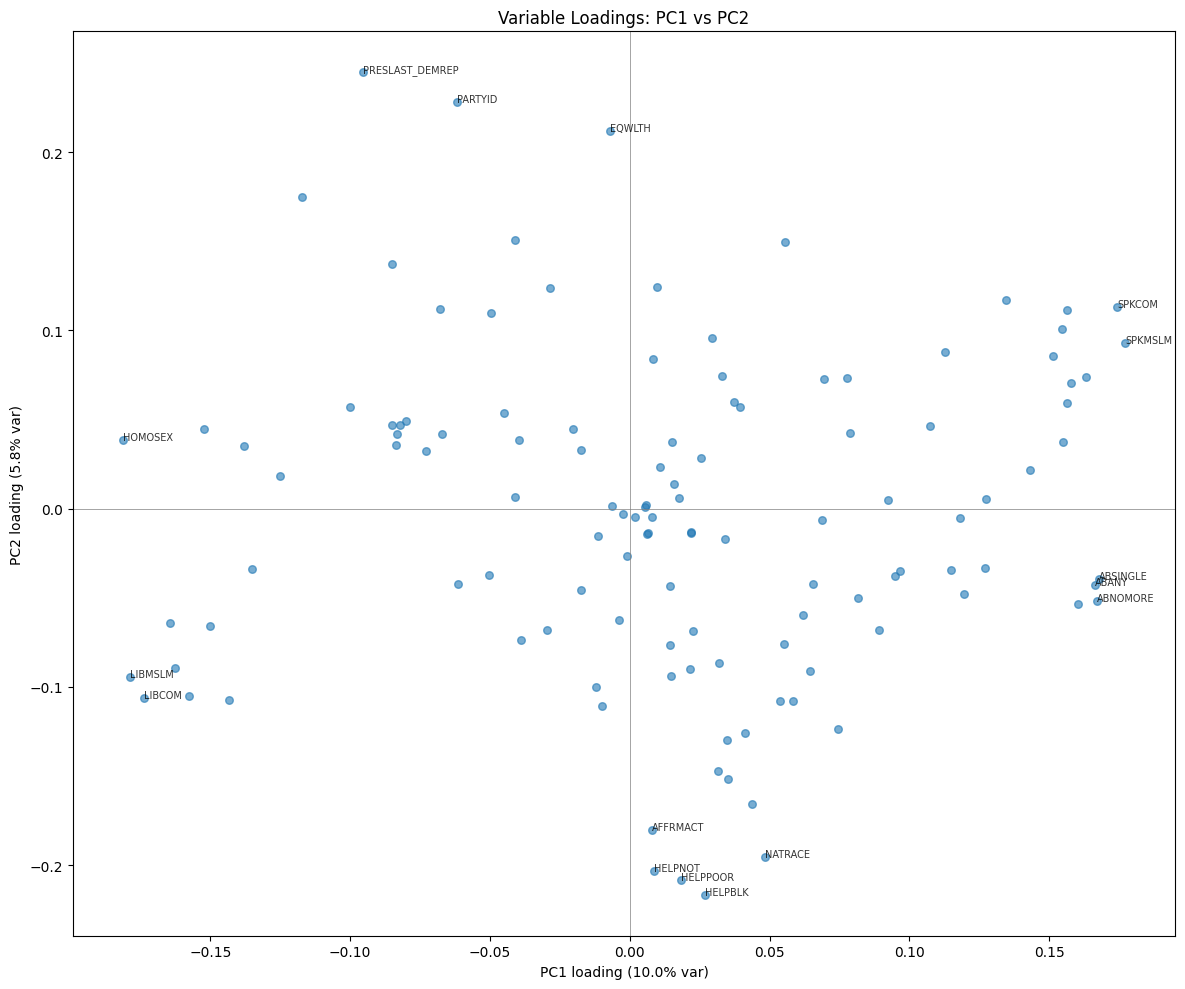

In [7]:
# PC1 vs PC2 loading scatter — where do variables live in PCA space?
fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(loadings['PC1'], loadings['PC2'], alpha=0.6, s=30)

# Label top-loaded variables on either axis
top_pc1 = loadings.nlargest(8, 'PC1_abs').index
top_pc2 = loadings.nlargest(8, 'PC2_abs').index
to_label = set(top_pc1) | set(top_pc2)

for var in to_label:
    ax.annotate(var, (loadings.loc[var, 'PC1'], loadings.loc[var, 'PC2']),
                fontsize=7, alpha=0.8)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 loading ({explained[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 loading ({explained[1]*100:.1f}% var)')
ax.set_title('Variable Loadings: PC1 vs PC2')
plt.tight_layout()
plt.show()

## 1.2 Network Stats

Basic structural properties of the reference network.

In [8]:
# Build NetworkX graph
corr_abs = corr_reg.copy()
np.fill_diagonal(corr_abs.values, 0)
G_ref = nx.from_pandas_adjacency(corr_abs.abs())
G_ref.remove_edges_from([(u, v) for u, v, d in G_ref.edges(data=True) if d['weight'] == 0])

stats = calculate_network_stats(G_ref)

print("=== Reference Network Stats (2000-2010) ===")
print(f"  Nodes:               {stats['num_nodes']}")
print(f"  Edges:               {stats['num_edges']}")
print(f"  Density:             {stats['density']:.4f}")
print(f"  Average degree:      {stats['avg_degree']:.2f}")
print(f"  Clustering coeff:    {stats['clustering_coefficient']:.4f}")
print(f"  Transitivity:        {stats['global_clustering_coefficient']:.4f}")

=== Reference Network Stats (2000-2010) ===
  Nodes:               121
  Edges:               376
  Density:             0.0518
  Average degree:      6.21
  Clustering coeff:    0.4497
  Transitivity:        0.4250


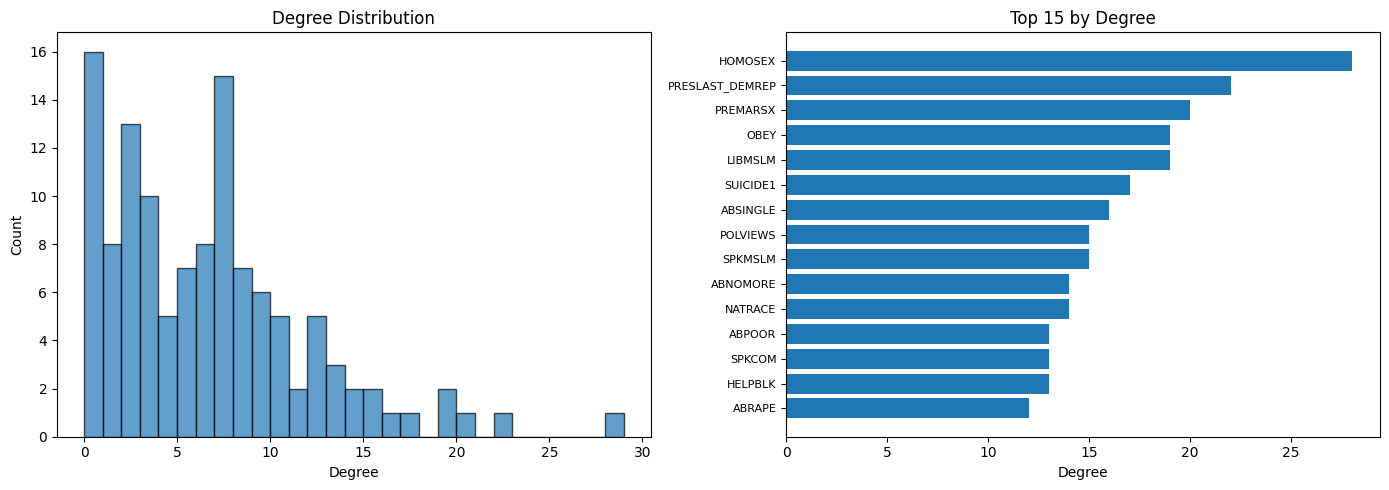

In [9]:
# Degree distribution
degrees = pd.Series(dict(G_ref.degree())).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degrees.values, bins=range(0, degrees.max() + 2), alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')
axes[0].set_title('Degree Distribution')

axes[1].barh(range(15), degrees.head(15).values)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(degrees.head(15).index, fontsize=8)
axes[1].set_xlabel('Degree')
axes[1].set_title('Top 15 by Degree')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 1.3 Community Detection

Do beliefs cluster into interpretable domains?

In [10]:
# Louvain community detection on absolute-weight graph
communities = nx.community.louvain_communities(G_ref, weight='weight', seed=42)

print(f"Number of communities: {len(communities)}")
print()

# Build node->community mapping
node_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_community[node] = i

# Display communities sorted by size
for i, comm in enumerate(sorted(communities, key=len, reverse=True)):
    print(f"Community {i+1} ({len(comm)} members): {sorted(comm)}")
    print()

Number of communities: 26

Community 1 (23 members): ['AFFRMACT', 'CAPPUN', 'COURTS', 'EQWLTH', 'HELPBLK', 'HELPNOT', 'HELPPOOR', 'NATAID', 'NATARMS', 'NATCITY', 'NATCRIME', 'NATDRUG', 'NATFARE', 'NATRACE', 'PARTYID', 'POLVIEWS', 'PRESLAST_DEMREP', 'RACDIF1', 'RACDIF2', 'RACDIF3', 'RACDIF4', 'WOULDVOTELAST_DEMREP', 'WRKWAYUP']

Community 2 (18 members): ['COLATH', 'COLCOM', 'COLHOMO', 'COLMIL', 'COLMSLM', 'COLRAC', 'LIBATH', 'LIBCOM', 'LIBHOMO', 'LIBMIL', 'LIBMSLM', 'LIBRAC', 'SPKATH', 'SPKCOM', 'SPKHOMO', 'SPKMIL', 'SPKMSLM', 'SPKRAC']

Community 3 (14 members): ['DIVLAW', 'FECHLD', 'FEFAM', 'FEPOL', 'FEPRESCH', 'GRASS', 'HOMOSEX', 'PORNLAW', 'PRAYER', 'PREMARSX', 'SEXEDUC', 'SPANKING', 'TEENSEX', 'XMARSEX']

Community 4 (12 members): ['CONARMY', 'CONBUS', 'CONEDUC', 'CONFED', 'CONFINAN', 'CONJUDGE', 'CONLABOR', 'CONLEGIS', 'CONMEDIC', 'CONPRESS', 'CONSCI', 'CONTV']

Community 5 (10 members): ['NATCHLD', 'NATEDUC', 'NATENRGY', 'NATENVIR', 'NATHEAL', 'NATMASS', 'NATPARK', 'NATSCI', 'NA

C:\Users\timbo\AppData\Local\Temp\ipykernel_30284\2932127843.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_communities)


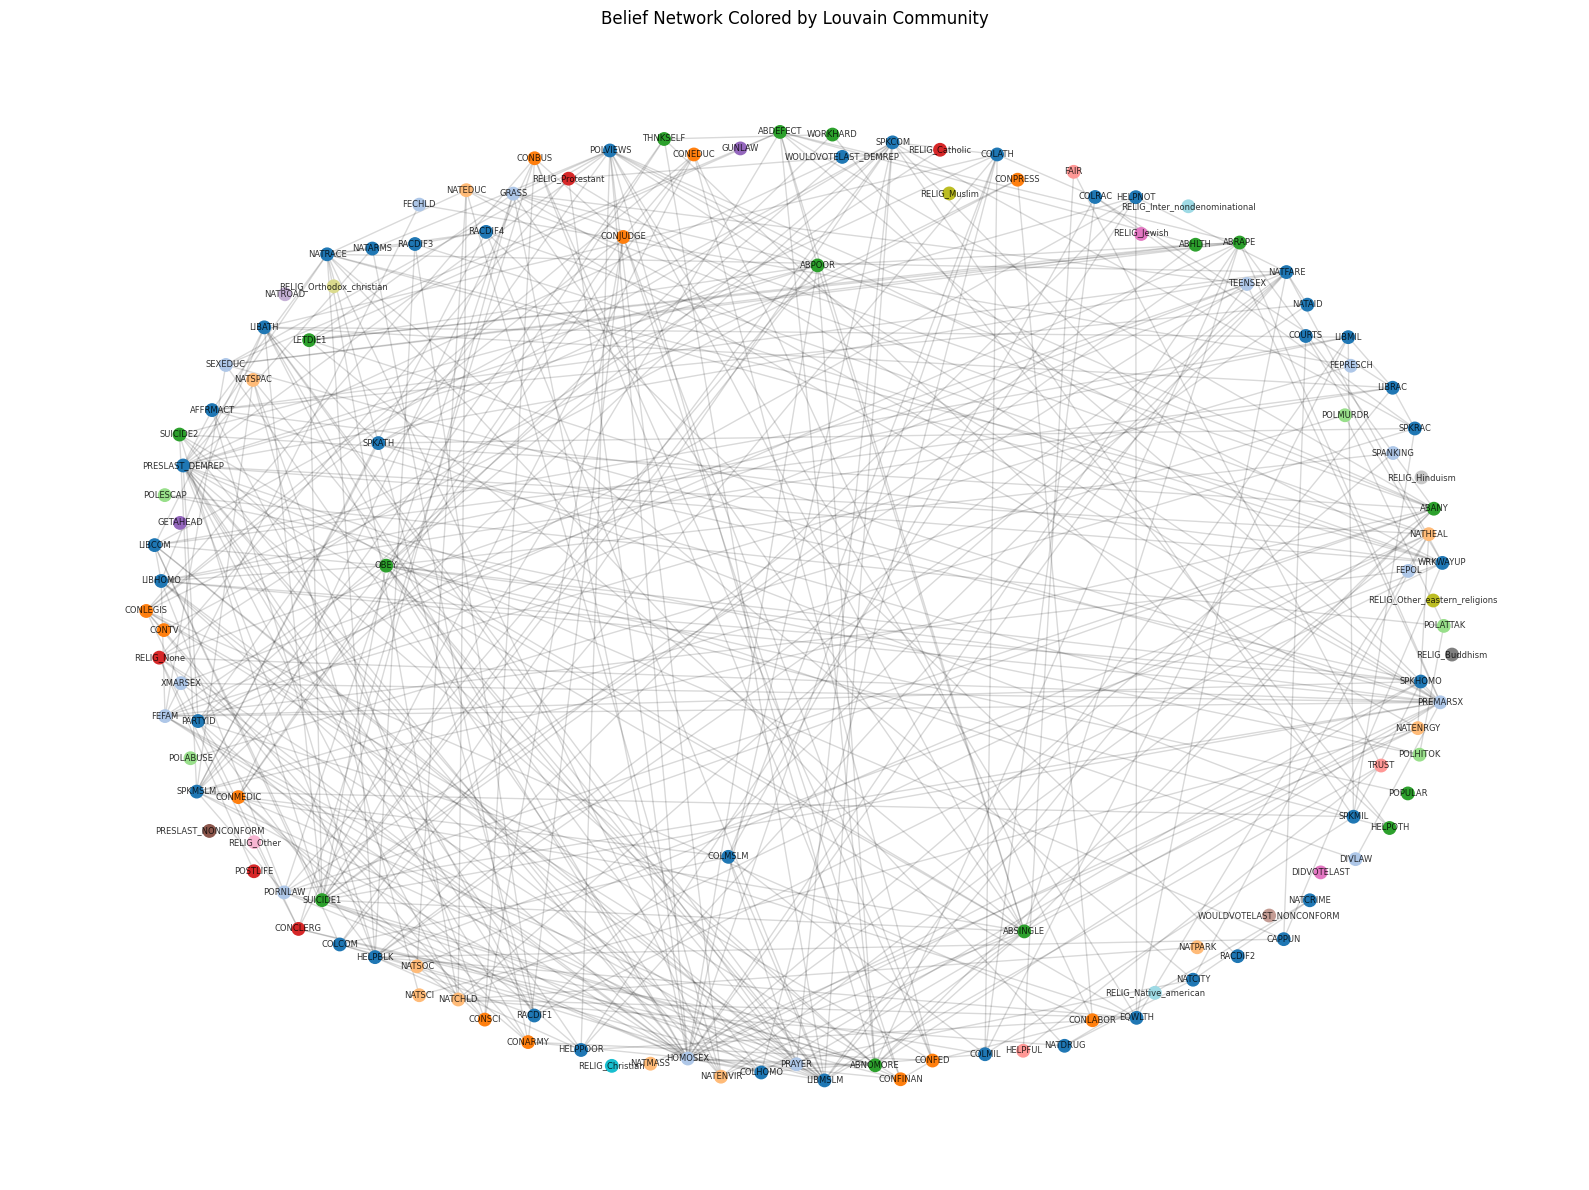

In [11]:
# Visualize network colored by community
fig, ax = plt.subplots(figsize=(16, 12))

pos = nx.spring_layout(G_ref, k=2, iterations=100, seed=42, weight='weight')

# Color map for communities
n_communities = len(communities)
cmap = plt.cm.get_cmap('tab20', n_communities)

# Sort communities by size for consistent coloring
sorted_comms = sorted(communities, key=len, reverse=True)
node_colors = []
for node in G_ref.nodes():
    for i, comm in enumerate(sorted_comms):
        if node in comm:
            node_colors.append(cmap(i))
            break

# Draw
nx.draw_networkx_edges(G_ref, pos, alpha=0.15, ax=ax)
nx.draw_networkx_nodes(G_ref, pos, node_color=node_colors, node_size=80, ax=ax)
nx.draw_networkx_labels(G_ref, pos, font_size=6, alpha=0.8, ax=ax)

ax.set_title('Belief Network Colored by Louvain Community')
ax.axis('off')
plt.tight_layout()
plt.show()

## 1.4 Centrality — With Dimensionality Context

**Key question:** Do the most central variables simply have the highest PC1 loadings?
Or are there genuinely interesting bridge variables?

In [12]:
# Compute centrality measures
bc_dict = nx.betweenness_centrality(G_ref, weight='weight')
degree_dict = dict(G_ref.degree())
strength_dict = {n: sum(d['weight'] for _, _, d in G_ref.edges(n, data=True)) for n in G_ref.nodes()}

# Combine with PCA loadings (only for variables in both the network and PCA)
centrality_df = pd.DataFrame({
    'degree': degree_dict,
    'betweenness': bc_dict,
    'strength': strength_dict,
})

# Join with loadings (inner join on common variables)
centrality_df = centrality_df.join(loadings[['PC1', 'PC1_abs', 'PC2', 'PC2_abs']], how='inner')
centrality_df.rename(columns={'PC1': 'PC1_loading', 'PC2': 'PC2_loading'}, inplace=True)

print("=== Top 15 by Betweenness ===")
print(centrality_df.sort_values('betweenness', ascending=False)[['betweenness', 'degree', 'PC1_abs']].head(15).to_string())

=== Top 15 by Betweenness ===
                 betweenness  degree   PC1_abs
OBEY                0.240056      19  0.135178
ABNOMORE            0.226751      14  0.167191
SPKCOM              0.218627      13  0.174259
POLVIEWS            0.200560      15  0.117245
HOMOSEX             0.199720      28  0.181232
PRESLAST_DEMREP     0.171429      22  0.095505
SPKMSLM             0.142857      15  0.177098
CONCLERG            0.138936       6  0.072913
ABSINGLE            0.138095      16  0.167743
PRAYER              0.120308      10  0.127310
WRKWAYUP            0.118067      11  0.084874
NATFARE             0.108403      12  0.043755
LIBMSLM             0.092717      19  0.178592
RACDIF4             0.090196       6  0.085050
ABRAPE              0.072829      12  0.127086


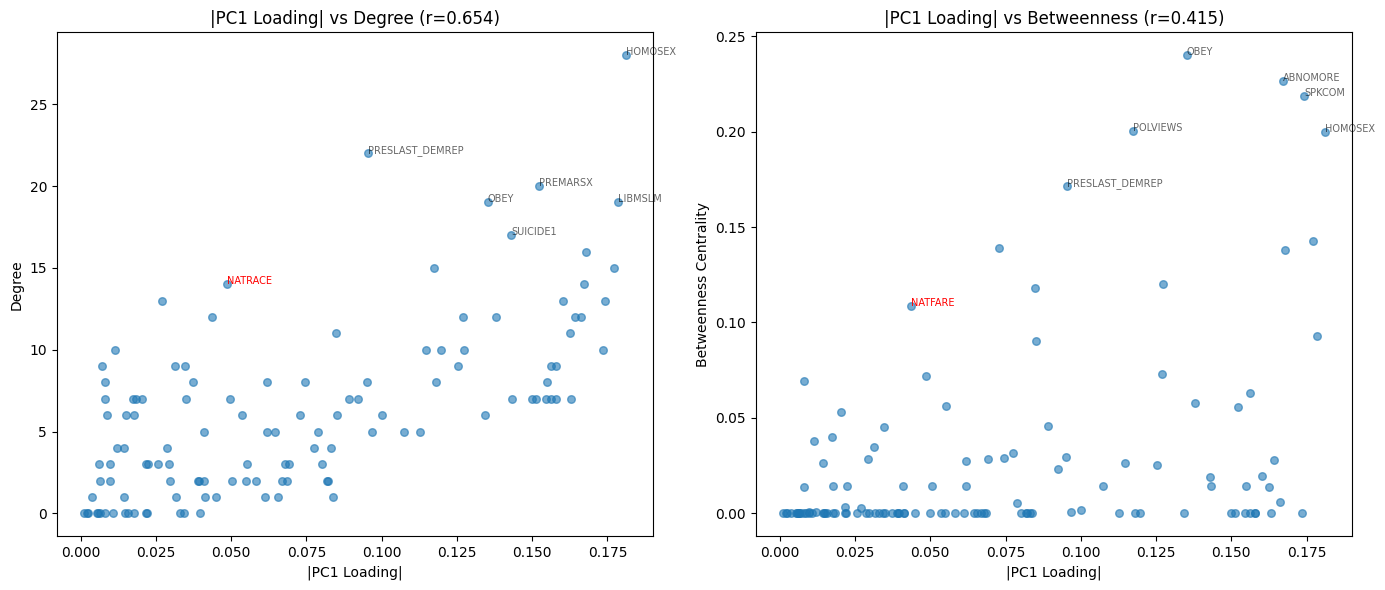


Correlation between |PC1 loading| and degree: r = 0.654
Correlation between |PC1 loading| and betweenness: r = 0.415

=> Degree is NOT simply a proxy for PC1 loading.
   Network centrality captures something beyond the dominant axis.


In [13]:
# Scatter: PC1 loading vs degree and betweenness
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1 vs Degree
axes[0].scatter(centrality_df['PC1_abs'], centrality_df['degree'], alpha=0.6, s=30)
r_deg = centrality_df[['PC1_abs', 'degree']].corr().iloc[0, 1]
axes[0].set_xlabel('|PC1 Loading|')
axes[0].set_ylabel('Degree')
axes[0].set_title(f'|PC1 Loading| vs Degree (r={r_deg:.3f})')

# Label outliers: high centrality but low PC1
for _, row in centrality_df.iterrows():
    if (row['degree'] > centrality_df['degree'].quantile(0.9) and
        row['PC1_abs'] < centrality_df['PC1_abs'].median()):
        axes[0].annotate(row.name, (row['PC1_abs'], row['degree']),
                        fontsize=7, color='red')
    elif (row['degree'] > centrality_df['degree'].quantile(0.95)):
        axes[0].annotate(row.name, (row['PC1_abs'], row['degree']),
                        fontsize=7, alpha=0.6)

# PC1 vs Betweenness
axes[1].scatter(centrality_df['PC1_abs'], centrality_df['betweenness'], alpha=0.6, s=30)
r_btw = centrality_df[['PC1_abs', 'betweenness']].corr().iloc[0, 1]
axes[1].set_xlabel('|PC1 Loading|')
axes[1].set_ylabel('Betweenness Centrality')
axes[1].set_title(f'|PC1 Loading| vs Betweenness (r={r_btw:.3f})')

# Label outliers
for _, row in centrality_df.iterrows():
    if (row['betweenness'] > centrality_df['betweenness'].quantile(0.9) and
        row['PC1_abs'] < centrality_df['PC1_abs'].median()):
        axes[1].annotate(row.name, (row['PC1_abs'], row['betweenness']),
                        fontsize=7, color='red')
    elif (row['betweenness'] > centrality_df['betweenness'].quantile(0.95)):
        axes[1].annotate(row.name, (row['PC1_abs'], row['betweenness']),
                        fontsize=7, alpha=0.6)

plt.tight_layout()
plt.show()

print(f"\nCorrelation between |PC1 loading| and degree: r = {r_deg:.3f}")
print(f"Correlation between |PC1 loading| and betweenness: r = {r_btw:.3f}")

if r_deg > 0.7:
    print("\n=> Degree is strongly predicted by PC1 loading.")
    print("   'Most connected' mostly means 'most aligned with the dominant axis.'")
else:
    print("\n=> Degree is NOT simply a proxy for PC1 loading.")
    print("   Network centrality captures something beyond the dominant axis.")

In [14]:
# Identify genuinely interesting bridge variables:
# high centrality but NOT highly loaded on PC1
median_pc1 = centrality_df['PC1_abs'].median()
high_cent = centrality_df['betweenness'] > centrality_df['betweenness'].quantile(0.75)
low_pc1 = centrality_df['PC1_abs'] < median_pc1

bridges = centrality_df[high_cent & low_pc1].sort_values('betweenness', ascending=False)

if len(bridges) > 0:
    print("=== Bridge Variables (high centrality, low PC1 loading) ===")
    print("These are central in the network but NOT aligned with the dominant axis.")
    print(bridges[['betweenness', 'degree', 'PC1_abs', 'PC1_loading']].to_string())
else:
    print("No variables are both high-centrality and low-PC1.")
    print("Centrality in this network is fully captured by the dominant dimension.")

=== Bridge Variables (high centrality, low PC1 loading) ===
These are central in the network but NOT aligned with the dominant axis.
          betweenness  degree   PC1_abs  PC1_loading
NATFARE      0.108403      12  0.043755     0.043755
NATRACE      0.071989      14  0.048461     0.048461
AFFRMACT     0.069328       8  0.008062     0.008062
POLHITOK     0.056022       3  0.055376     0.055376
CONFINAN     0.052941       7  0.020248    -0.020248
NATHEAL      0.045378       9  0.034624     0.034624
CONFED       0.039916       7  0.017379    -0.017379
CONLEGIS     0.037955      10  0.011297    -0.011297
NATCHLD      0.034734       9  0.031415     0.031415


## 1.5 Balance with Null Model

**Key question:** Is 99% balance surprising, or does any network with this structure produce similar balance?

Null model: keep the graph structure and absolute edge weights, randomly flip edge signs
(preserving the overall fraction of positive/negative edges). Repeat 1,000 times.

In [15]:
# Observed balance
triad_result = count_triads(corr_reg, return_names=True)
obs_pos = triad_result['positive_triads']
obs_neg = triad_result['negative_triads']
obs_total = obs_pos + obs_neg
obs_balance = obs_pos / obs_total if obs_total > 0 else np.nan

print(f"Observed: {obs_pos} balanced / {obs_neg} unbalanced = {obs_balance*100:.1f}% balanced")
print(f"Total triads: {obs_total}")

Observed: 516 balanced / 5 unbalanced = 99.0% balanced
Total triads: 521


In [16]:
%%time

# Null model: sign-shuffle test
# Keep the adjacency structure and absolute weights.
# Randomly assign signs, preserving the observed fraction of positive edges.

corr_vals = corr_reg.values.copy()
np.fill_diagonal(corr_vals, 0)

# Get upper triangle edges
triu_mask = np.triu(np.ones_like(corr_vals, dtype=bool), k=1)
edge_weights = corr_vals[triu_mask]
nonzero_mask = edge_weights != 0
nonzero_weights = edge_weights[nonzero_mask]
n_positive = (nonzero_weights > 0).sum()
n_negative = (nonzero_weights < 0).sum()
n_edges = len(nonzero_weights)
frac_positive = n_positive / n_edges

print(f"Edge sign distribution: {n_positive} positive, {n_negative} negative")
print(f"Fraction positive: {frac_positive:.3f}")
print(f"Running 1000 sign-shuffle permutations...")

rng = np.random.default_rng(42)
null_balances = []

for _ in range(1000):
    # Create shuffled matrix: same structure, random signs
    shuffled = np.zeros_like(corr_vals)
    abs_weights = np.abs(nonzero_weights)
    # Randomly assign positive/negative, preserving the fraction
    signs = np.ones(n_edges)
    neg_indices = rng.choice(n_edges, size=n_negative, replace=False)
    signs[neg_indices] = -1
    signed_weights = abs_weights * signs
    
    # Place back into matrix
    shuffled[triu_mask] = 0  # reset
    shuffled[triu_mask & (corr_vals != 0)] = 0  # we'll fill only nonzero positions
    
    # Rebuild upper triangle with shuffled signs
    full_upper = np.zeros(triu_mask.sum())
    full_upper[nonzero_mask] = signed_weights
    shuffled[triu_mask] = full_upper
    shuffled = shuffled + shuffled.T  # symmetrize
    
    # Count triads
    shuffled_df = pd.DataFrame(shuffled, index=corr_reg.index, columns=corr_reg.columns)
    result = count_triads(shuffled_df)
    null_pos = result['positive_triads']
    null_total = null_pos + result['negative_triads']
    if null_total > 0:
        null_balances.append(null_pos / null_total)

null_balances = np.array(null_balances)
print(f"Done. Null distribution: mean={null_balances.mean():.3f}, "
      f"std={null_balances.std():.3f}, "
      f"range=[{null_balances.min():.3f}, {null_balances.max():.3f}]")

Edge sign distribution: 243 positive, 133 negative
Fraction positive: 0.646
Running 1000 sign-shuffle permutations...


Done. Null distribution: mean=0.512, std=0.022, range=[0.441, 0.576]
CPU times: total: 1min 47s
Wall time: 1min 47s


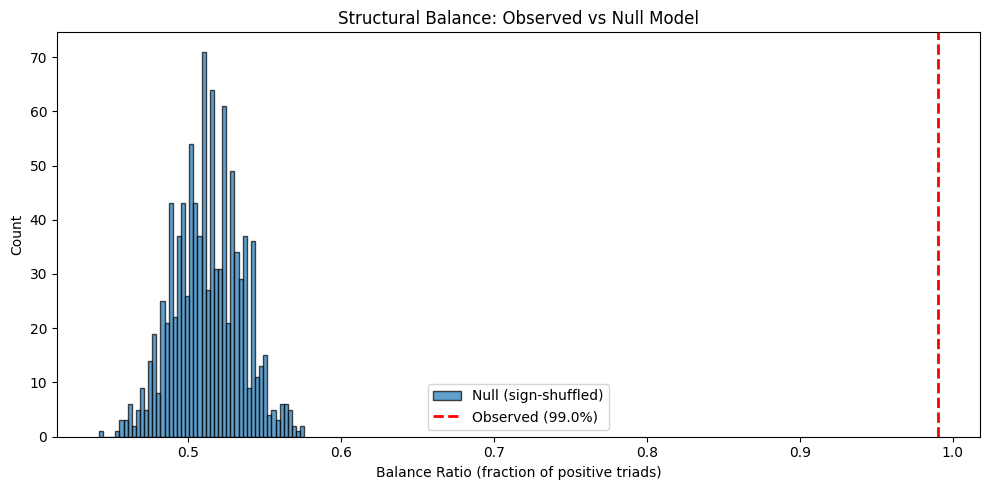


Observed balance: 99.0%
Null mean:        51.2%
Null std:         2.2%
p-value (one-sided, observed >= null): 0.0000

=> Balance is SIGNIFICANTLY higher than expected by chance.
   The belief network has genuine structural balance beyond what
   the degree sequence and sign distribution would predict.


In [17]:
# Compare observed to null
p_value = (null_balances >= obs_balance).mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(null_balances, bins=50, alpha=0.7, edgecolor='black', label='Null (sign-shuffled)')
ax.axvline(obs_balance, color='red', linewidth=2, linestyle='--',
           label=f'Observed ({obs_balance*100:.1f}%)')
ax.set_xlabel('Balance Ratio (fraction of positive triads)')
ax.set_ylabel('Count')
ax.set_title('Structural Balance: Observed vs Null Model')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nObserved balance: {obs_balance*100:.1f}%")
print(f"Null mean:        {null_balances.mean()*100:.1f}%")
print(f"Null std:         {null_balances.std()*100:.1f}%")
print(f"p-value (one-sided, observed >= null): {p_value:.4f}")

if p_value < 0.05:
    print("\n=> Balance is SIGNIFICANTLY higher than expected by chance.")
    print("   The belief network has genuine structural balance beyond what")
    print("   the degree sequence and sign distribution would predict.")
else:
    print("\n=> Balance is NOT significantly higher than expected.")
    print("   The high balance ratio is a trivial consequence of having")
    print(f"   {frac_positive*100:.0f}% positive edges — any network with this")
    print("   sign distribution would show similar balance.")

## 1.6 Visualization

Interactive HTML visualization (same as baseline) plus community-colored static plot.

In [18]:
output_path = str(Path.cwd().parent / 'outputs' / 'sound_reference_network_2000_2010.html')
Path(output_path).parent.mkdir(parents=True, exist_ok=True)

generate_html_visualization(
    corr_reg,
    output_path=output_path,
    highlight_nodes=['POLVIEWS', 'PARTYID']
)

print(f"Interactive visualization saved to: {output_path}")

Network visualization has been saved to C:\Users\timbo\Github\BeliefNetworkEvo\outputs\sound_reference_network_2000_2010.html
Interactive visualization saved to: C:\Users\timbo\Github\BeliefNetworkEvo\outputs\sound_reference_network_2000_2010.html


## Summary

See `analyses/2026-02_sound-single-network.md` for the full writeup.